In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_ribbon import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(2, 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        stretching_energy = 0.5 * (self.K[0] * del_strain[0]**2 + self.K[0] * del_strain[1]**2)
        bending_energy = 0.5 * (self.K[1] * del_strain[3]**2)

        # mlp contribution
        # combine del_strain[0] and del_strain[1] since they both represent stretching in x and y directions
        mlp_input = jnp.array([(del_strain[0]**2 + del_strain[1]**2), del_strain[3]**2])
        mlp_energy = self.mlp(mlp_input)
        # return stretching_energy + bending_energy + mlp_energy
        return stretching_energy + bending_energy



In [3]:
# train_datafile = "experiment_data/train_from_experiment.npz"
# valid_datafile = "experiment_data/train_from_experiment.npz"

train_datafile = "ribbon/train_direct_bc.npz"
valid_datafile = "ribbon/train_direct_bc.npz"

init_K=jnp.array([0.03, 0.000005])
validate_model(Example, der_K=init_K)

# final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-3, init_K=init_K )
final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=200, lr=1e-3, init_K=init_K )

# final_model = Example(der_K=init_K, key=jax.random.PRNGKey(42))

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

lk:  0.005000000000000001
EA:  2.000000000000001
EI1:  0.006666666666666665
EI2:  2.666666666666667
GJ:  0.004444444444444444
Initial training loss: 2.04961e-06
K: [3.e-02 5.e-06]
grad K: [-1.17060155e-06 -6.65883730e-02]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-03  | Train: 2.04961e-06  | Valid: 3.65138e-08  | K: [0.03099153 0.001005  ]
Step 10   | LR: 9.945e-04  | Train: 2.48144e-08  | Valid: 2.52214e-08  | K: [0.03776161 0.00435853]
Step 20   | LR: 9.782e-04  | Train: 2.49188e-08  | Valid: 2.46936e-08  | K: [0.04706572 0.00535414]
Step 30   | LR: 9.514e-04  | Train: 2.34746e-08  | Valid: 2.33790e-08  | K: [0.05325595 0.00573118]
Step 40   | LR: 9.149e-04  | Train: 2.26726e-08  | Valid: 2.26097e-08  | K: [0.05657081 0.00587379]
Step 50   | LR: 8.694e-04  | Train: 2.20914e-08  | Valid: 2.20872e-08  | K: [0.05878111 0.00592508]
Step 60   | LR: 8.162e-04  | Train: 2.16691e-08  | Valid: 2.18376e-08  | K: [0.06047098 0.00594189]
Step 70   | LR: 7.565e-04  | Train: 2.1268

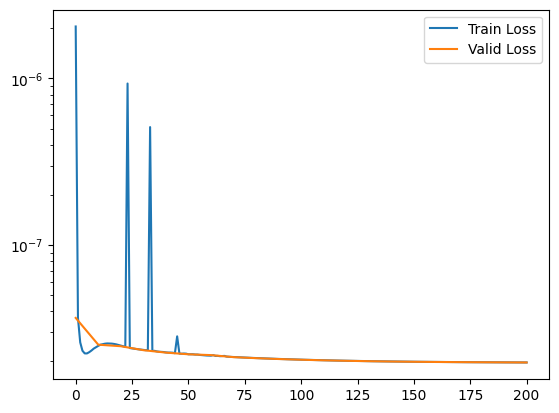

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (1, 101, 32)
lk:  0.005000000000000001
EA:  2.000000000000001
EI1:  0.006666666666666665
EI2:  2.666666666666667
GJ:  0.004444444444444444
xb.shape (1, 101, 32)
pred.shape (1, 101, 83)
valid.qs.shape (1, 101, 83)
train.qs.shape (1, 101, 83)


In [9]:
# animate(valid.qs)

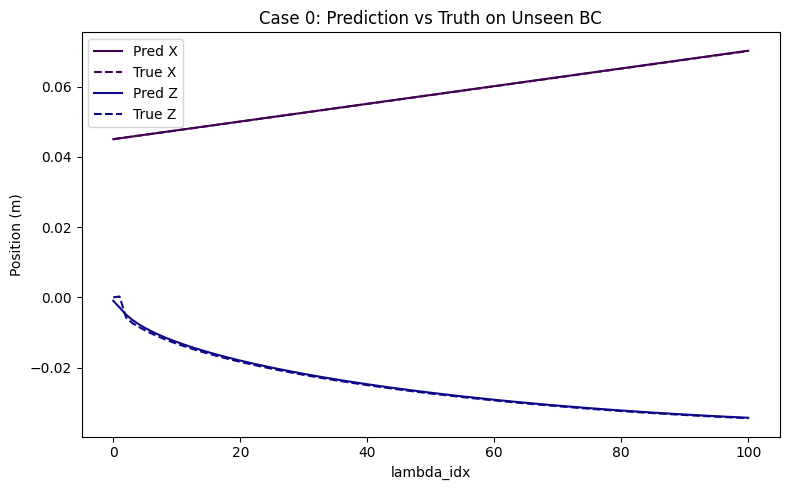

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 36], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 36], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 38], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 38], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.004       0.          0.          0.          0.009       0.
   0.          0.          0.01394714 -0.         -0.00071467  0.
   0.01877164  0.         -0.002022    0.          0.02346209  0.
  -0.00374968  0.          0.02806348  0.         -0.00570227  0.
   0.03265453  0.         -0.00767902  0.          0.03731596  0.
  -0.00948351  0.          0.0420998   0.         -0.01093247  0.
   0.04700942  0.         -0.01187051  0.          0.05199751  0.
  -0.01219122  0.          0.05698473  0.         -0.0118571   0.
   0.06189217  0.         -0.01090778  0.          0.06667379  0.
  -0.00945145  0.          0.07133433  0.         -0.00764465  0.
   0.07592668  0.         -0.00567087  0.          0.0805312   0.
  -0.00372565  0.          0.08522524  0.         -0.00200774  0.
   0.09005219  0.         -0.00070952  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0045      0.          0.          0.          0.0095  

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01197081 -0.         -0.00052669  0.
   0.01687808  0.         -0.00147825  0.          0.02171886  0.
  -0.00272479  0.          0.02651826  0.         -0.00412228  0.
   0.03131642  0.         -0.00552397  0.          0.0361522   0.
  -0.00678975  0.          0.04104874  0.         -0.007795    0.
   0.04600556  0.         -0.00844032  0.          0.05099929  0.
  -0.00866136  0.          0.05599284  0.         -0.00843603  0.
   0.06094921  0.         -0.00778722  0.          0.06584534  0.
  -0.00677993  0.          0.07068106  0.         -0.00551386  0.
   0.07547964  0.         -0.00411355  0.          0.08027979  0.
  -0.00271861  0.          0.08512133  0.         -0.00147492  0.
   0.09002905  0.         -0.00052562  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0.   

In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01197081 -0.         -0.00052669  0.
   0.01687808  0.         -0.00147825  0.          0.02171886  0.
  -0.00272479  0.          0.02651826  0.         -0.00412228  0.
   0.03131642  0.         -0.00552397  0.          0.0361522   0.
  -0.00678975  0.          0.04104874  0.         -0.007795    0.
   0.04600556  0.         -0.00844032  0.          0.05099929  0.
  -0.00866136  0.          0.05599284  0.         -0.00843603  0.
   0.06094921  0.         -0.00778722  0.          0.06584534  0.
  -0.00677993  0.          0.07068106  0.         -0.00551386  0.
   0.07547964  0.         -0.00411355  0.          0.08027979  0.
  -0.00271861  0.          0.08512133  0.         -0.00147492  0.
   0.09002905  0.         -0.00052562  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0. 

In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01195891  0.         -0.00045548  0.
   0.01686799  0.         -0.00129334  0.          0.02172191  0.
  -0.00240824  0.          0.0265386   0.         -0.00367496  0.
   0.03135044  0.         -0.00495989  0.          0.03619102  0.
  -0.0061312   0.          0.04108201  0.         -0.0070687   0.
   0.04602479  0.         -0.00767448  0.          0.051       0.
  -0.00788396  0.          0.05597521  0.         -0.00767448  0.
   0.06091799  0.         -0.0070687   0.          0.06580898  0.
  -0.0061312   0.          0.07064956  0.         -0.00495989  0.
   0.0754614   0.         -0.00367496  0.          0.08027809  0.
  -0.00240824  0.          0.08513201  0.         -0.00129334  0.
   0.09004109  0.         -0.00045548  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0.      